<a href="https://colab.research.google.com/github/RajeshMameda/climate_data_analysis/blob/main/climate_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
file_name = "/content/_46ff4a66b0c34464a2c688ad218c762c_climate_temperature_regional_1980_2020.nc"

In [5]:
ds = xr.open_dataset(file_name)
print(ds)

<xarray.Dataset> Size: 6kB
Dimensions:      (time: 492)
Dimensions without coordinates: time
Data variables:
    year         (time) int32 2kB ...
    month        (time) int32 2kB ...
    temperature  (time) float32 2kB ...
Attributes:
    title:          Regional Monthly Mean Surface Air Temperature 1980-2020
    institution:    Sustainability Analytics — Climate Data Preparation Activity
    source:         Synthetic regional climate dataset for educational use
    history:        Created 2026-06-29
    comment:        Monthly mean surface air temperature for a mid-latitude r...
    baseline_note:  Suggested baseline period: 1981-2010 (WMO standard 30-yea...
    conventions:    CF-1.8
    time_range:     1980-01 to 2020-12
    total_months:   492


In [10]:
print(ds)
print("\nDataset title:", ds.attrs["title"])
print("Time range:", ds.attrs["time_range"])
print("Total months:", ds.attrs["total_months"])
print("Temperature units:", ds["temperature"].attrs["units"])
print(
    "Missing values:",
    int(ds["temperature"].isnull().sum().values)
)

<xarray.Dataset> Size: 6kB
Dimensions:      (time: 492)
Dimensions without coordinates: time
Data variables:
    year         (time) int32 2kB ...
    month        (time) int32 2kB ...
    temperature  (time) float32 2kB ...
Attributes:
    title:          Regional Monthly Mean Surface Air Temperature 1980-2020
    institution:    Sustainability Analytics — Climate Data Preparation Activity
    source:         Synthetic regional climate dataset for educational use
    history:        Created 2026-06-29
    comment:        Monthly mean surface air temperature for a mid-latitude r...
    baseline_note:  Suggested baseline period: 1981-2010 (WMO standard 30-yea...
    conventions:    CF-1.8
    time_range:     1980-01 to 2020-12
    total_months:   492

Dataset title: Regional Monthly Mean Surface Air Temperature 1980-2020
Time range: 1980-01 to 2020-12
Total months: 492
Temperature units: degrees_Celsius
Missing values: 0


In [11]:
df = pd.DataFrame({
    "year":ds["year"].values,
    "month":ds["month"].values,
    "temperature":ds["temperature"].values
})

print(df.head())
print(df.tail())

   year  month  temperature
0  1980      1      -3.2223
1  1980      2      -2.5549
2  1980      3      -1.6932
3  1980      4      -0.2856
4  1980      5       1.2261
     year  month  temperature
487  2020      8       3.5866
488  2020      9       2.6433
489  2020     10       1.1718
490  2020     11      -1.0192
491  2020     12      -1.8066


In [19]:
annual_data = (
    df.groupby("year", as_index=False)["temperature"]
      .mean()
)

annual_data = annual_data.rename(
    columns={"temperature": "annual_temperature"}
)

print(annual_data.head())

   year  annual_temperature
0  1980           -0.224383
1  1981           -0.118567
2  1982           -0.125925
3  1983           -0.214558
4  1984           -0.084300


In [22]:
baseline_data = annual_data[
    annual_data["year"].between(1981, 2010)
]

baseline_mean = baseline_data[
    "annual_temperature"
].mean()

print("Baseline period: 1981–2010")
print("Baseline mean:", round(baseline_mean, 4), "°C")

Baseline period: 1981–2010
Baseline mean: 0.2338 °C


In [23]:
annual_data["anomaly"] = (
    annual_data["annual_temperature"] - baseline_mean
)

print(annual_data.head())
print(annual_data.tail())

   year  annual_temperature   anomaly
0  1980           -0.224383 -0.458185
1  1981           -0.118567 -0.352369
2  1982           -0.125925 -0.359727
3  1983           -0.214558 -0.448360
4  1984           -0.084300 -0.318102
    year  annual_temperature   anomaly
36  2016            0.712042  0.478240
37  2017            0.835825  0.602023
38  2018            0.855158  0.621356
39  2019            0.946942  0.713140
40  2020            0.877917  0.644115


In [24]:
annual_data["decade"] = (
    annual_data["year"] // 10
) * 10

print(
    annual_data[
        ["year", "anomaly", "decade"]
    ].head(15)
)

    year   anomaly  decade
0   1980 -0.458185    1980
1   1981 -0.352369    1980
2   1982 -0.359727    1980
3   1983 -0.448360    1980
4   1984 -0.318102    1980
5   1985 -0.281569    1980
6   1986 -0.337744    1980
7   1987 -0.217744    1980
8   1988 -0.259744    1980
9   1989 -0.176810    1980
10  1990 -0.194002    1990
11  1991 -0.153585    1990
12  1992 -0.167019    1990
13  1993 -0.040185    1990
14  1994 -0.082735    1990


In [25]:
annual_data["decade"] = (
    annual_data["year"] // 10
) * 10

print(
    annual_data[
        ["year", "anomaly", "decade"]
    ].head(15)
)

    year   anomaly  decade
0   1980 -0.458185    1980
1   1981 -0.352369    1980
2   1982 -0.359727    1980
3   1983 -0.448360    1980
4   1984 -0.318102    1980
5   1985 -0.281569    1980
6   1986 -0.337744    1980
7   1987 -0.217744    1980
8   1988 -0.259744    1980
9   1989 -0.176810    1980
10  1990 -0.194002    1990
11  1991 -0.153585    1990
12  1992 -0.167019    1990
13  1993 -0.040185    1990
14  1994 -0.082735    1990


In [26]:
decade_data = (
    annual_data.groupby("decade", as_index=False)["anomaly"]
               .mean()
)

decade_data["decade_label"] = (
    decade_data["decade"].astype(str) + "s"
)

decade_data.loc[
    decade_data["decade"] == 2020,
    "decade_label"
] = "2020"

print(decade_data)

   decade   anomaly decade_label
0    1980 -0.321035        1980s
1    1990 -0.034195        1990s
2    2000  0.266896        2000s
3    2010  0.517693        2010s
4    2020  0.644115         2020


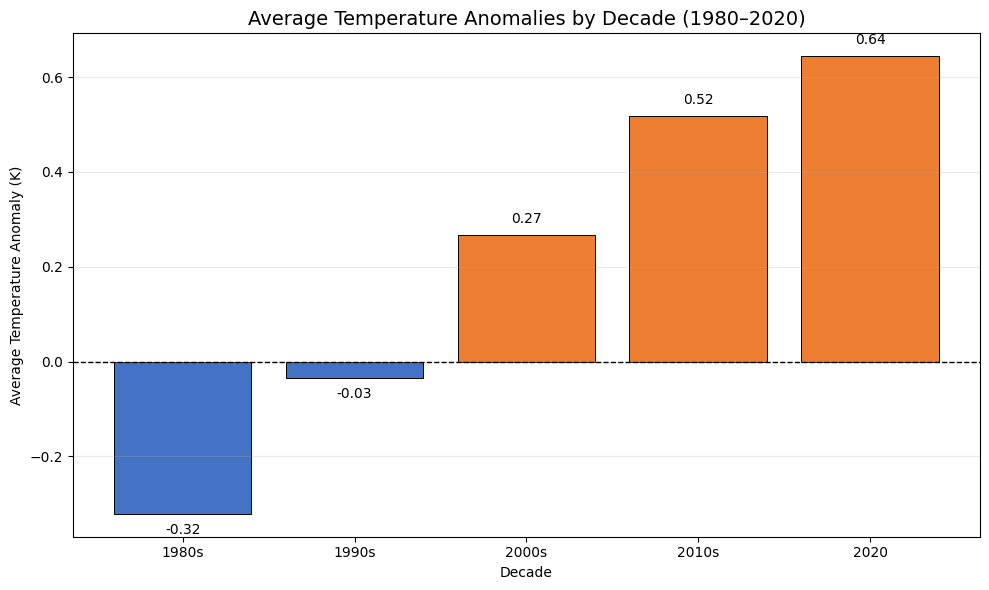

In [27]:
plt.figure(figsize=(10, 6))

colors = [
    "#4472C4" if value < 0 else "#ED7D31"
    for value in decade_data["anomaly"]
]

bars = plt.bar(
    decade_data["decade_label"],
    decade_data["anomaly"],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Average Temperature Anomalies by Decade (1980–2020)",
    fontsize=14
)

plt.xlabel("Decade")
plt.ylabel("Average Temperature Anomaly (K)")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(
    bars,
    decade_data["anomaly"]
):
    if value >= 0:
        position = value + 0.02
        alignment = "bottom"
    else:
        position = value - 0.02
        alignment = "top"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        position,
        f"{value:.2f}",
        ha="center",
        va=alignment,
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "temperature_anomalies_by_decade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()